Library

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("Eager execution:", tf.executing_eagerly())

TensorFlow version: 2.21.0
Eager execution: True


(Data Wrangling: Gathering Data)

In [6]:
base_dir = './' 
train_dir = os.path.join(base_dir, 'train')

if os.path.exists(train_dir):
    print("Gathering Data Berhasil: Folder ditemukan.")
else:
    print("Error: Folder 'train' tidak ditemukan di lokasi script.")

Gathering Data Berhasil: Folder ditemukan.


(Data Wrangling: Assessing Data)

In [7]:
print("--- Memulai Assessing Data ---")
categories = os.listdir(train_dir)
for category in categories:
    folder_path = os.path.join(train_dir, category)
    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        print(f"Kategori: {category:10} | Jumlah: {count} gambar")
print("--- Assessing Selesai ---")

--- Memulai Assessing Data ---
Kategori: Kaca       | Jumlah: 888 gambar
Kategori: Kardus     | Jumlah: 499 gambar
Kategori: Kertas     | Jumlah: 1445 gambar
Kategori: Logam      | Jumlah: 968 gambar
Kategori: Organik    | Jumlah: 1013 gambar
Kategori: Plastik    | Jumlah: 1005 gambar
--- Assessing Selesai ---


(Data Wrangling: Cleaning Data)

In [8]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest',
    validation_split=0.2 
)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 4657 images belonging to 6 classes.
Found 1161 images belonging to 6 classes.


 DATA DICTIONARY 

In [55]:
def map_to_group(label):
    organic_list = ['organik'] 
    
    if label.lower() in organic_list:
        return 'Organik (Sampah Basah)'
    else:
        return 'Anorganik (Daur Ulang)'

print("--- Data Dictionary: Klasifikasi Industri ---")
class_indices = train_generator.class_indices
for name, idx in class_indices.items():
    group = map_to_group(name)
    print(f"Folder: {name:10} -> Kelompok: {group}")

--- Data Dictionary: Klasifikasi Industri ---
Folder: Kaca       -> Kelompok: Anorganik (Daur Ulang)
Folder: Kardus     -> Kelompok: Anorganik (Daur Ulang)
Folder: Kertas     -> Kelompok: Anorganik (Daur Ulang)
Folder: Logam      -> Kelompok: Anorganik (Daur Ulang)
Folder: Organik    -> Kelompok: Organik (Sampah Basah)
Folder: Plastik    -> Kelompok: Anorganik (Daur Ulang)


EDA

Menampilkan Sampel: Organik vs Non-Organik


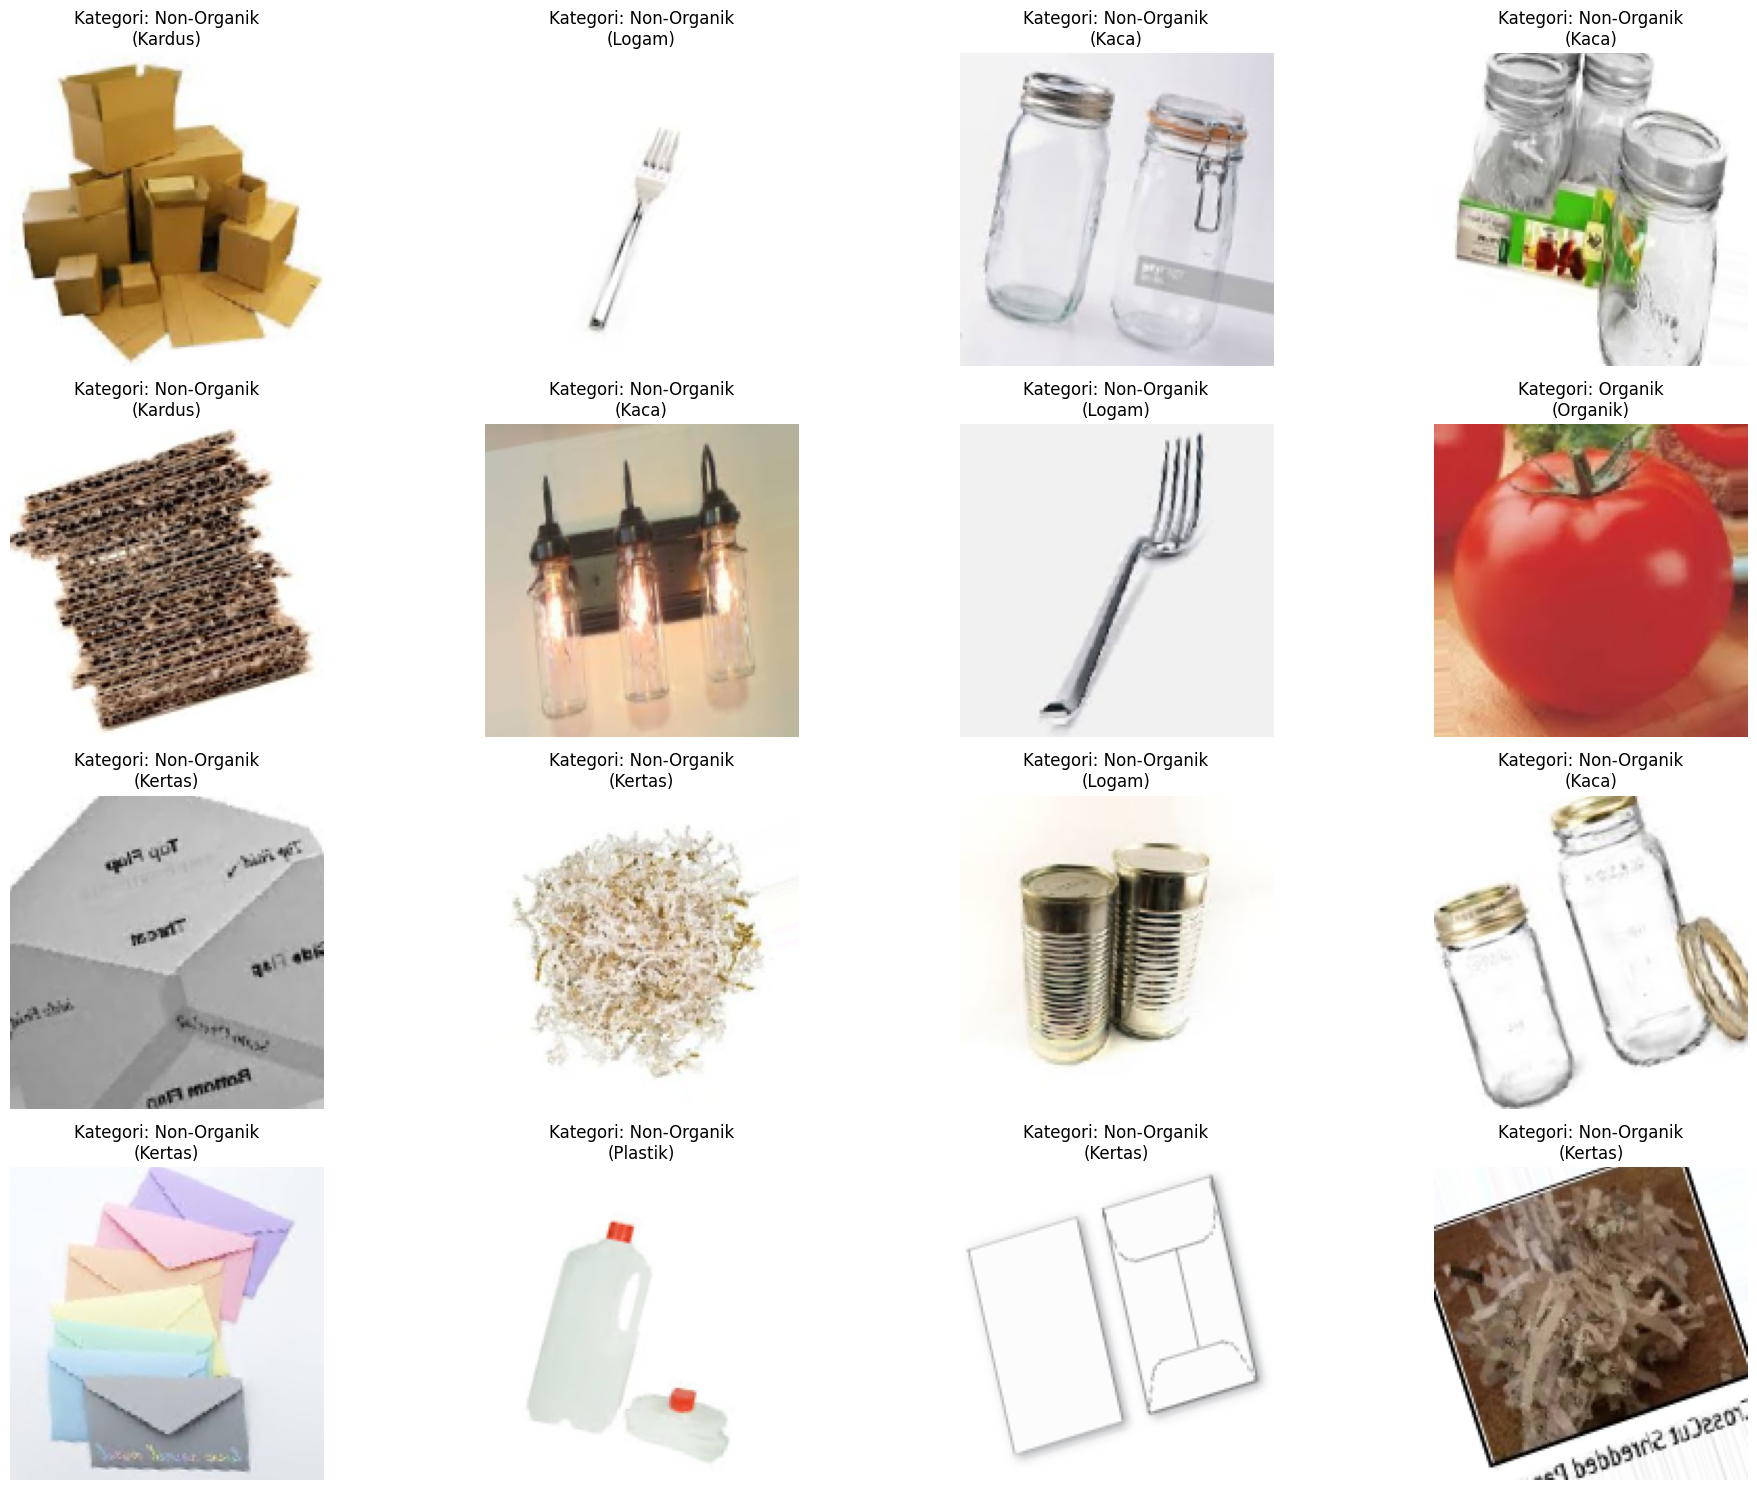

In [56]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(20, 15))

images, labels = next(train_generator)

print("===================================")
print("Menampilkan Sampel: Organik vs Non-Organik")
print("===================================")

for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(images[i])
    
    idx = np.argmax(labels[i])
    original_name = labels_map[idx]
    display_name = map_to_binary(original_name)

    plt.title(f"Kategori: {display_name}\n({original_name})", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

Defining Business Questions
1. Bagaimana distribusi jumlah gambar untuk setiap kategori sampah (Kaca, Kardus, Kertas, Logam, Organik, Plastik)?
2. Apakah dataset memiliki variasi visual yang cukup (seperti sisa makanan pada kategori Organik) untuk melatih model secara objektif?
3. Kategori mana yang memiliki jumlah data paling dominan atau paling sedikit yang berpotensi menyebabkan ketidakseimbangan data (data imbalance)?

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data_info = []
for category in os.listdir(train_dir):
    path = os.path.join(train_dir, category)
    if os.path.isdir(path):
        data_info.append({
            "Kategori": category,
            "Jumlah_Gambar": len(os.listdir(path))
        })

df_eda = pd.DataFrame(data_info)

print("--- Insight Struktur Data ---")
print(df_eda.sort_values(by="Jumlah_Gambar", ascending=False))

--- Insight Struktur Data ---
  Kategori  Jumlah_Gambar
2   Kertas           1445
4  Organik           1013
5  Plastik           1005
3    Logam            968
0     Kaca            888
1   Kardus            499


C:\Users\Yildi Andriana\AppData\Local\Temp\ipykernel_2124\2317287873.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Kelompok', y='Jumlah_Gambar', data=df_grouped, palette='Set2')


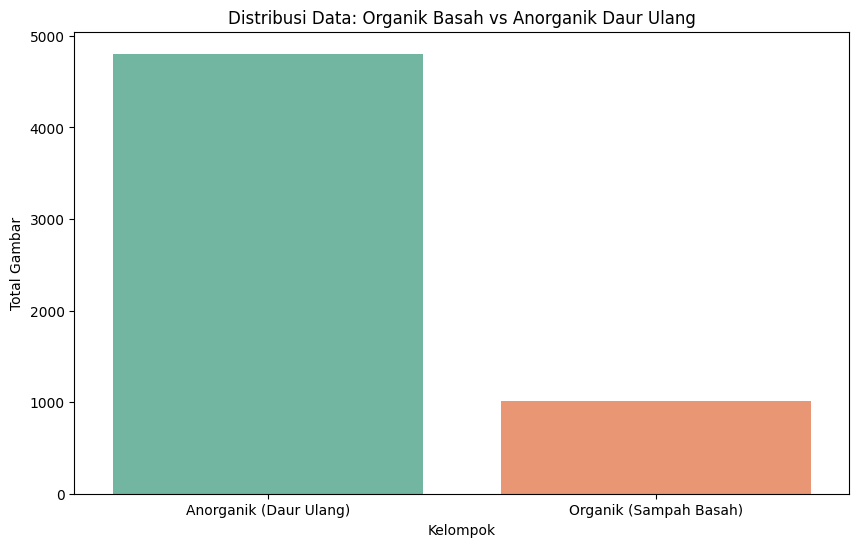

Insight: Terdapat 1013 gambar yang siap didaur ulang (termasuk kertas).


In [58]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Menghitung distribusi berdasarkan kelompok baru
df_eda['Kelompok'] = df_eda['Kategori'].apply(map_to_group)
df_grouped = df_eda.groupby('Kelompok')['Jumlah_Gambar'].sum().reset_index()

# Visualisasi Bar Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Kelompok', y='Jumlah_Gambar', data=df_grouped, palette='Set2')
plt.title('Distribusi Data: Organik Basah vs Anorganik Daur Ulang')
plt.ylabel('Total Gambar')
plt.show()

print(f"Insight: Terdapat {df_grouped.iloc[1,1]} gambar yang siap didaur ulang (termasuk kertas).")

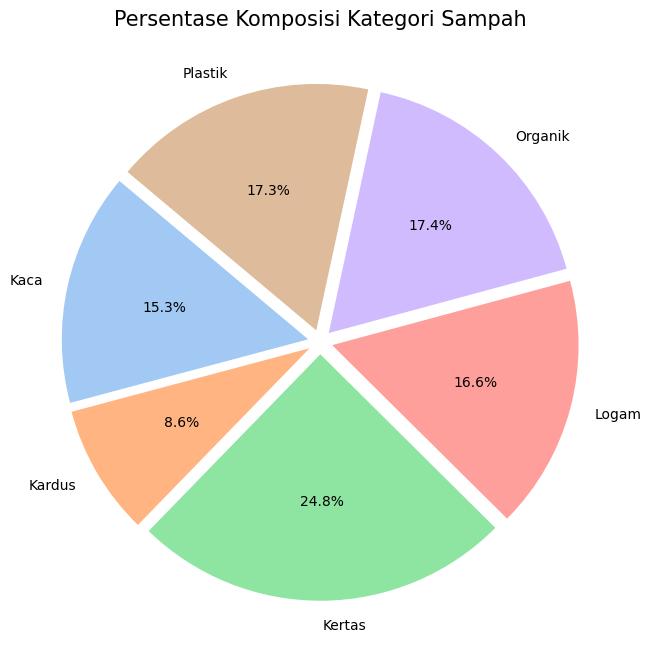

In [59]:
plt.figure(figsize=(10, 8))
colors = sns.color_palette('pastel')[0:6]

# Membuat Pie Chart
plt.pie(df_eda['Jumlah_Gambar'], 
        labels=df_eda['Kategori'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=colors,
        explode=[0.05] * 6) 

plt.title("Persentase Komposisi Kategori Sampah", fontsize=15)
plt.show()


Feature Engineering

In [60]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    
    Flatten(),
    
    Dropout(0.5), 
    
    Dense(512, activation='relu'),
    
    Dense(6, activation='softmax') 
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\Yildi Andriana\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,036,742 (72.62 MB)

 Trainable params: 19,036,742 (72.62 MB)

 Non-trainable params: 0 (0.00 B)

Model Training

In [ ]:
history = model.fit(
    train_generator,
    epochs=20, # Jumlah putaran pelatihan
    validation_data=validation_generator,
    verbose=1
)

A/B Testing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# --- 1. Explanatory Analysis: Visualisasi Training ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Grafik Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Grafik Loss')
plt.legend()
plt.show()

# --- 2. A/B Testing: Evaluasi pada Data Validasi ---
loss, accuracy = model.evaluate(validation_generator)
print(f"\nHasil Evaluasi Akhir (A/B Testing): Akurasi sebesar {accuracy*100:.2f}%")

# --- 3. Classification Report (Detail Per Kategori) ---
Y_pred = model.predict(validation_generator)
y_pred = np.argmax(Y_pred, axis=1)

print('\nClassification Report:')
target_names = list(train_generator.class_indices.keys())
print(classification_report(validation_generator.classes, y_pred, target_names=target_names))

Save model

In [ ]:
model.save('model_sampah_final.h5')